# 📊 Statistics Practice Guide - Kaggle Dataset

**Dataset**: Tips Dataset (restaurant tips data)

**Yeh notebook tumhe sikhayega:**
- Har statistical concept ko practically kaise calculate kare
- Real data pe kaise apply kare
- Interpretation kaise kare (insight kaise nikale)

---

## 🔧 Step 1: Setup & Data Loading

In [2]:
# Libraries import karo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [3]:
# Dataset load karo (Seaborn mein built-in hai)
df = sns.load_dataset('tips')

# Pehle 10 rows dekho
print("📋 First 10 rows:")
print(df.head(10))

print("\n📊 Dataset Info:")
print(df.info())
print(df.isnull().sum())

print("\n🔢 Dataset Shape:", df.shape)

📋 First 10 rows:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
5       25.29  4.71    Male     No  Sun  Dinner     4
6        8.77  2.00    Male     No  Sun  Dinner     2
7       26.88  3.12    Male     No  Sun  Dinner     4
8       15.04  1.96    Male     No  Sun  Dinner     2
9       14.78  3.23    Male     No  Sun  Dinner     2

📊 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-nu

---
## 📈 PART 1: Measures of Central Tendency

**Central Tendency = Data ka center kahan hai?**

Hum `total_bill` column pe practice karenge.

### 1.1 Mean (Average)

**Formula**: Sum of all values / Number of values

**Kab use kare**: Jab data mein extreme outliers na ho

**Example**: Class ke students ki average height

📊 Mean of Total Bill: $19.79
📊 Mean (NumPy): $19.79
📊 Mean (Manual): $19.79


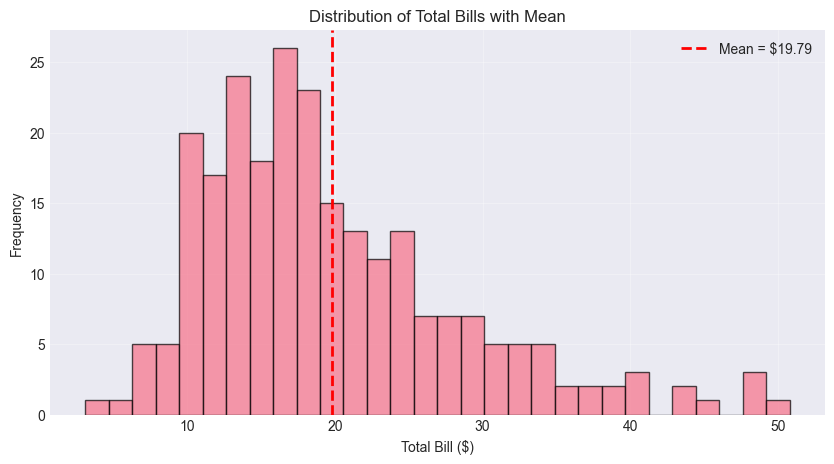


💡 Interpretation: Average bill restaurant mein approximately $19.79 hai


In [4]:
# METHOD 1: Pandas se
mean_bill = df['total_bill'].mean()
print(f"📊 Mean of Total Bill: ${mean_bill:.2f}")

# METHOD 2: Numpy se
mean_bill_np = np.mean(df['total_bill'])
print(f"📊 Mean (NumPy): ${mean_bill_np:.2f}")

# METHOD 3: Manual calculation
mean_manual = df['total_bill'].sum() / len(df['total_bill'])
print(f"📊 Mean (Manual): ${mean_manual:.2f}")

# Visualization
plt.figure(figsize=(10, 5))
plt.hist(df['total_bill'], bins=30, alpha=0.7, edgecolor='black')
plt.axvline(mean_bill, color='red', linestyle='--', linewidth=2, label=f'Mean = ${mean_bill:.2f}')
plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Total Bills with Mean')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 Interpretation: Average bill restaurant mein approximately $19.79 hai")

### 1.2 Median (Middle Value)

**Formula**: Data ko sort karo, beech wali value lo

**Kab use kare**: Jab outliers ho (extremely high/low values)

**Example**: City mein median house price (kyunki kuch bahut expensive houses hote hain)

📊 Median of Total Bill: $17.80
📊 Median (NumPy): $17.80


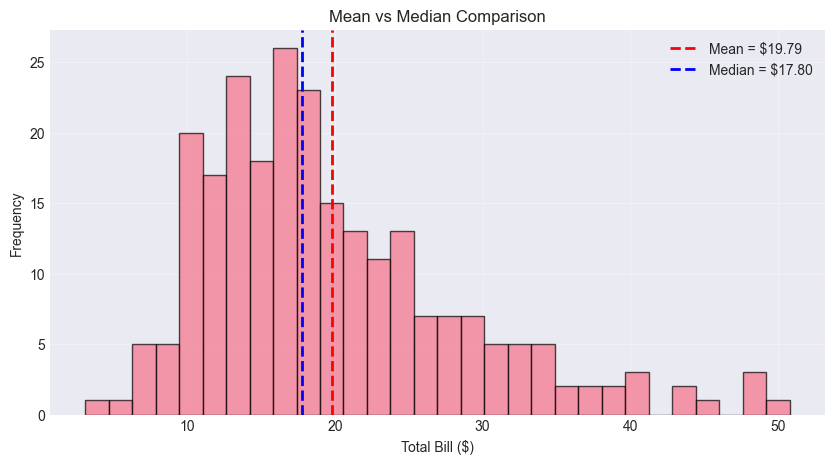


💡 Interpretation:
   Mean > Median → Data RIGHT-SKEWED hai (kuch high bills hain)


In [5]:
# METHOD 1: Pandas se
median_bill = df['total_bill'].median()
print(f"📊 Median of Total Bill: ${median_bill:.2f}")

# METHOD 2: Numpy se
median_bill_np = np.median(df['total_bill'])
print(f"📊 Median (NumPy): ${median_bill_np:.2f}")

# Visualization - Mean vs Median
plt.figure(figsize=(10, 5))
plt.hist(df['total_bill'], bins=30, alpha=0.7, edgecolor='black')
plt.axvline(mean_bill, color='red', linestyle='--', linewidth=2, label=f'Mean = ${mean_bill:.2f}')
plt.axvline(median_bill, color='blue', linestyle='--', linewidth=2, label=f'Median = ${median_bill:.2f}')
plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')
plt.title('Mean vs Median Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 Interpretation:")
if mean_bill > median_bill:
    print("   Mean > Median → Data RIGHT-SKEWED hai (kuch high bills hain)")
elif mean_bill < median_bill:
    print("   Mean < Median → Data LEFT-SKEWED hai")
else:
    print("   Mean = Median → Data SYMMETRIC hai")

### 1.3 Mode (Most Frequent Value)

**Formula**: Sabse zyada baar repeat hone wali value

**Kab use kare**: Categorical data ke liye best (colors, sizes, etc.)

**Example**: Most common shirt size in a store

📊 Mode of Total Bill: $13.42
📊 Most common day: Sat
📊 Most common time: Dinner
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


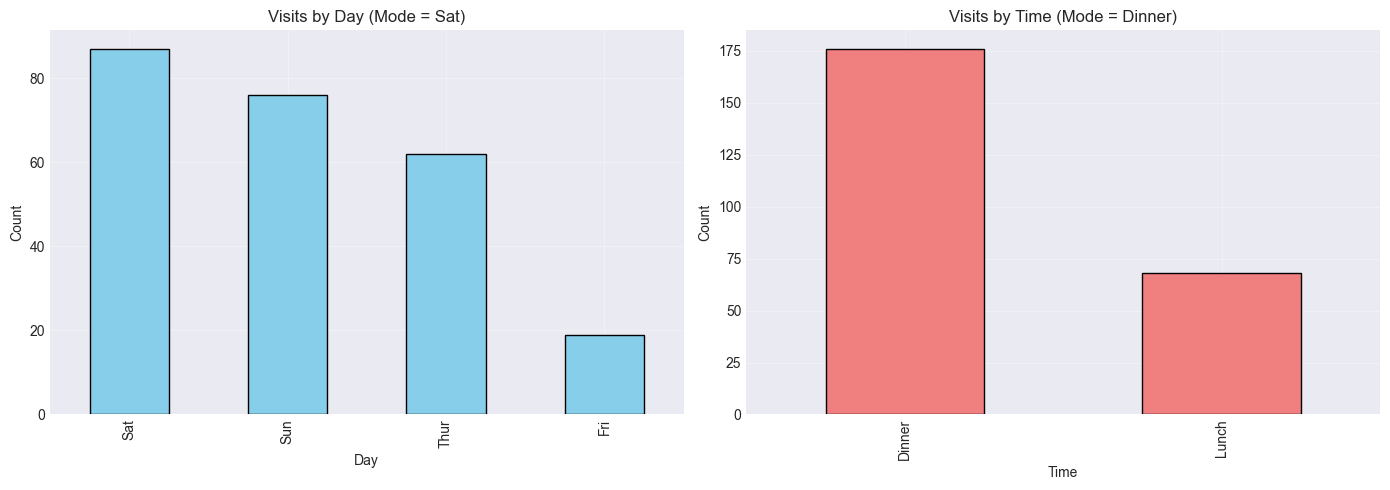


💡 Interpretation: Most people visit on Saturday during Dinner


In [6]:
# Numerical column pe mode
mode_bill = df['total_bill'].mode()[0]  # [0] kyunki mode ek Series return karta hai
print(f"📊 Mode of Total Bill: ${mode_bill:.2f}")

# Categorical column pe mode (zyada useful)
mode_day = df['day'].mode()[0]
print(f"📊 Most common day: {mode_day}")

mode_time = df['time'].mode()[0]
print(f"📊 Most common time: {mode_time}")

# Visualization - Categorical mode
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day wise count
print(df["day"].value_counts())
df['day'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title(f'Visits by Day (Mode = {mode_day})')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# Time wise count
df['time'].value_counts().plot(kind='bar', ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title(f'Visits by Time (Mode = {mode_time})')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Interpretation: Most people visit on Saturday during Dinner")

### 🎯 Practice Exercise 1

**Task**: `tip` column ke liye Mean, Median, Mode calculate karo aur visualization banao

In [7]:
# YOUR CODE HERE
# Hint: df['tip'] use karo

mean_tip = df['tip'].mean()
median_tip = df['tip'].median()
mode_tip = df['tip'].mode()[0]

print(f"Mean Tip: ${mean_tip:.2f}")
print(f"Median Tip: ${median_tip:.2f}")
print(f"Mode Tip: ${mode_tip:.2f}")

Mean Tip: $3.00
Median Tip: $2.90
Mode Tip: $2.00


---
## 📏 PART 2: Measures of Dispersion

**Dispersion = Data kitna spread hai (scatter/variation)?**

### 2.1 Range

**Formula**: Maximum value - Minimum value

**Matlab**: Data ka total spread kitna hai

**Limitation**: Outliers se bahut affect hota hai

📊 Minimum Bill: $3.07
📊 Maximum Bill: $50.81
📊 Range: $47.74


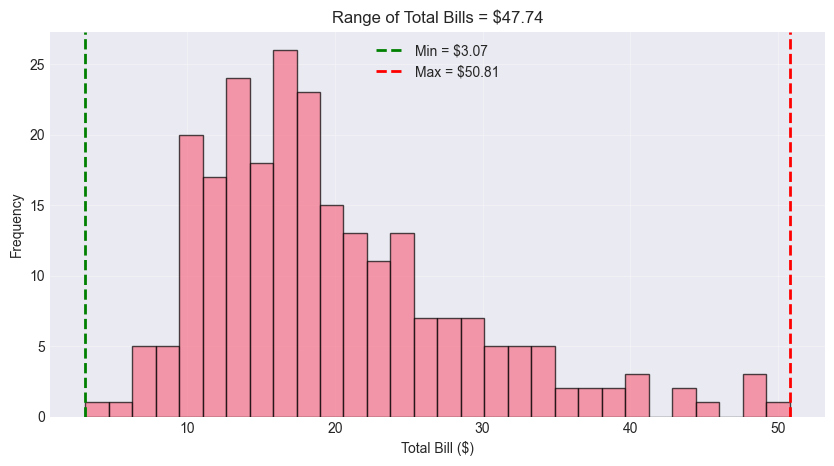


💡 Interpretation: Bills $3.07 se lekar $50.81 tak hain (spread of $47.74)


In [8]:
# Range calculation
min_bill = df["total_bill"].min()
max_bill = df["total_bill"].max()
range_bill = max_bill - min_bill

print(f"📊 Minimum Bill: ${min_bill:.2f}")
print(f"📊 Maximum Bill: ${max_bill:.2f}")
print(f"📊 Range: ${range_bill:.2f}")

# Visualization
plt.figure(figsize=(10, 5))
plt.hist(df["total_bill"], bins=30, alpha=0.7, edgecolor="black")
plt.axvline(
    min_bill, color="green", linestyle="--", linewidth=2, label=f"Min = ${min_bill:.2f}"
)
plt.axvline(
    max_bill, color="red", linestyle="--", linewidth=2, label=f"Max = ${max_bill:.2f}"
)
plt.xlabel("Total Bill ($)")
plt.ylabel("Frequency")
plt.title(f"Range of Total Bills = ${range_bill:.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 Interpretation: Bills $3.07 se lekar $50.81 tak hain (spread of $47.74)")

### 2.2 Variance

**Formula**: Average of squared differences from mean

**Matlab**: Data points mean se kitna door hain (squared)

**Unit**: Original unit ka square (agar bill dollars mein hai, toh variance dollars² mein)

In [9]:
# Variance calculation
variance_bill = df['total_bill'].var()
print(f"📊 Variance (Pandas): {variance_bill:.2f}") # 79.25

# NumPy se (population variance)
variance_np = np.var(df['total_bill'])
print(f"📊 Variance (NumPy - Population): {variance_np:.2f}")  # 78.83

# Manual calculation (to understand formula)
mean = df['total_bill'].mean()
squared_diff = (df['total_bill'] - mean) ** 2
variance_manual = squared_diff.sum() / (len(df['total_bill']) - 1)  # Sample variance
print(f"📊 Variance (Manual - Sample): {variance_manual:.2f}")  # 79.25

print("\n⚠️ Note: Pandas uses sample variance (n-1), NumPy uses population variance (n)")
print("\n💡 Interpretation: Higher variance = More spread in data")

📊 Variance (Pandas): 79.25
📊 Variance (NumPy - Population): 78.93
📊 Variance (Manual - Sample): 79.25

⚠️ Note: Pandas uses sample variance (n-1), NumPy uses population variance (n)

💡 Interpretation: Higher variance = More spread in data


### 2.3 Standard Deviation (SD)

**Formula**: Square root of Variance

**Matlab**: Variance ko original unit mein convert karta hai

**Most Important**: Sabse zyada use hota hai dispersion measure

📊 Standard Deviation: $8.90
📊 Standard Deviation (NumPy): $8.90
📊 Standard Deviation (Manual): $8.90


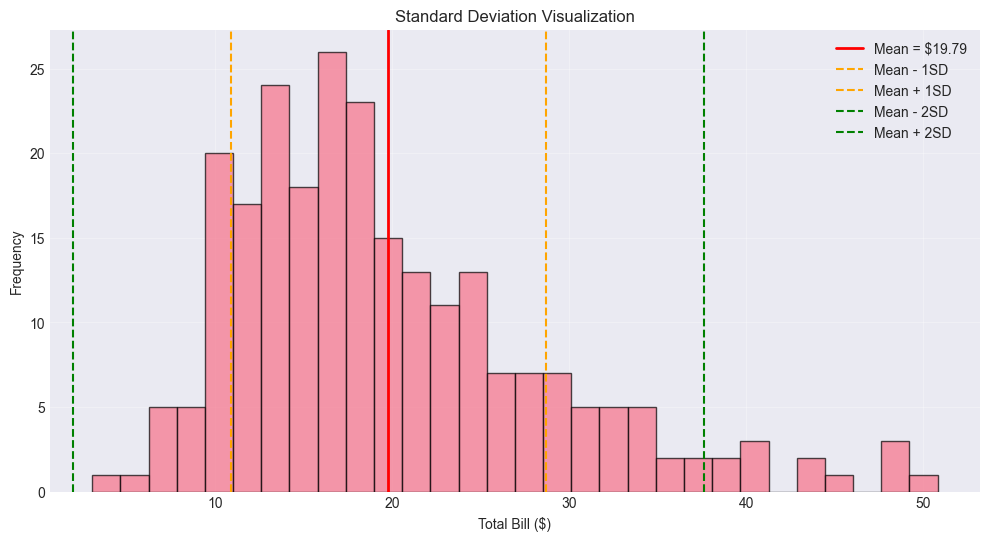


📈 72.1% data points are within 1 SD of mean
   (Normal distribution mein ~68% hota hai)

💡 Interpretation: Most bills are within $8.90 of the mean


In [10]:
# Standard Deviation calculation
std_bill = df['total_bill'].std()
print(f"📊 Standard Deviation: ${std_bill:.2f}")

# NumPy se
std_np = np.std(df['total_bill'], ddof=1)  # ddof=1 for sample std
print(f"📊 Standard Deviation (NumPy): ${std_np:.2f}")

# Manual
std_manual = np.sqrt(variance_bill)
print(f"📊 Standard Deviation (Manual): ${std_manual:.2f}")

# Visualization - Mean ± 1 SD, ± 2 SD
plt.figure(figsize=(12, 6))
plt.hist(df['total_bill'], bins=30, alpha=0.7, edgecolor='black')

# Mean line
plt.axvline(mean_bill, color='red', linestyle='-', linewidth=2, label=f'Mean = ${mean_bill:.2f}')

# Mean ± 1 SD
plt.axvline(mean_bill - std_bill, color='orange', linestyle='--', linewidth=1.5, label=f'Mean - 1SD')
plt.axvline(mean_bill + std_bill, color='orange', linestyle='--', linewidth=1.5, label=f'Mean + 1SD')

# Mean ± 2 SD
plt.axvline(mean_bill - 2*std_bill, color='green', linestyle='--', linewidth=1.5, label=f'Mean - 2SD')
plt.axvline(mean_bill + 2*std_bill, color='green', linestyle='--', linewidth=1.5, label=f'Mean + 2SD')

plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')
plt.title('Standard Deviation Visualization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 68-95-99.7 Rule (Empirical Rule for Normal Distribution)
within_1sd = df[(df['total_bill'] >= mean_bill - std_bill) & 
                 (df['total_bill'] <= mean_bill + std_bill)]
percentage_1sd = (len(within_1sd) / len(df)) * 100

print(f"\n📈 {percentage_1sd:.1f}% data points are within 1 SD of mean")
print("   (Normal distribution mein ~68% hota hai)")

print("\n💡 Interpretation: Most bills are within $" + f"{std_bill:.2f} of the mean")

### 2.4 Coefficient of Variation (CV)

**Formula**: (Standard Deviation / Mean) × 100

**Matlab**: Relative variability (unit-free measure)

**Kab use kare**: Do different datasets compare karne ke liye

📊 Coefficient of Variation (Total Bill): 44.99%
📊 Coefficient of Variation (Tip): 46.15%


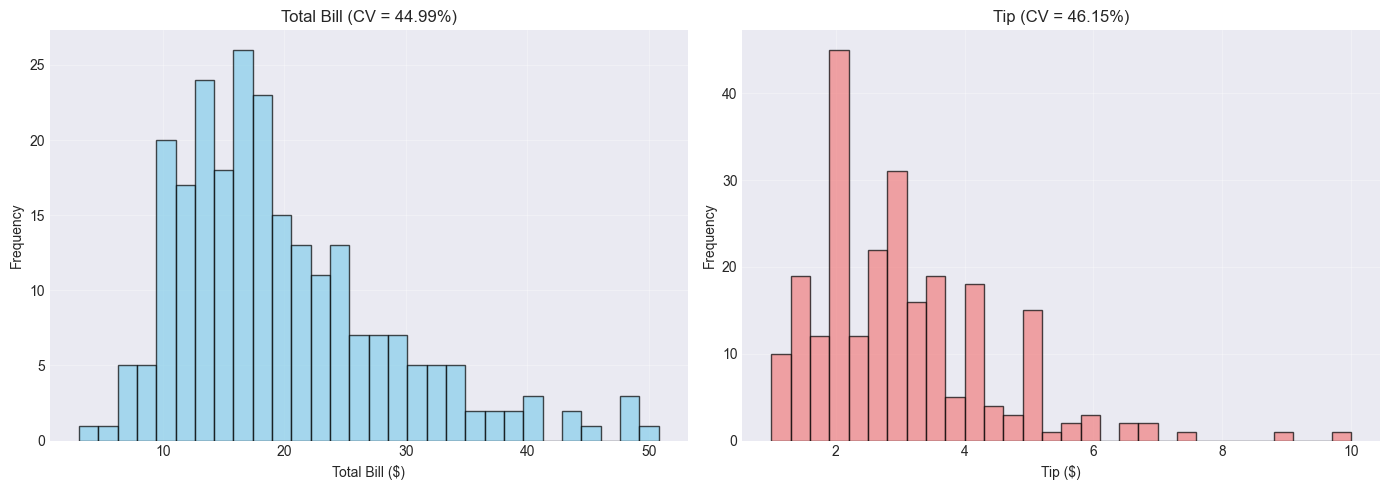


💡 Interpretation:
   Tip has MORE relative variability than Total Bill

   CV < 15%: Low variability
   CV 15-30%: Moderate variability
   CV > 30%: High variability


In [11]:
# Coefficient of Variation
cv_bill = (std_bill / mean_bill) * 100
print(f"📊 Coefficient of Variation (Total Bill): {cv_bill:.2f}%")

# Compare karte hain total_bill aur tip
cv_tip = (df['tip'].std() / df['tip'].mean()) * 100
print(f"📊 Coefficient of Variation (Tip): {cv_tip:.2f}%")

# Comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['total_bill'], bins=30, alpha=0.7, edgecolor='black', color='skyblue')
axes[0].set_title(f'Total Bill (CV = {cv_bill:.2f}%)')
axes[0].set_xlabel('Total Bill ($)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['tip'], bins=30, alpha=0.7, edgecolor='black', color='lightcoral')
axes[1].set_title(f'Tip (CV = {cv_tip:.2f}%)')
axes[1].set_xlabel('Tip ($)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
if cv_bill > cv_tip:
    print("   Total Bill has MORE relative variability than Tip")
else:
    print("   Tip has MORE relative variability than Total Bill")
print("\n   CV < 15%: Low variability")
print("   CV 15-30%: Moderate variability")
print("   CV > 30%: High variability")

---
## 🎯 PART 3: Percentiles & Quantiles

### 3.1 Percentiles

**Matlab**: Data ko 100 parts mein divide karna

**Example**: 90th percentile = 90% data is values are below this

📊 Percentiles of Total Bill:
   25th percentile (Q1): $13.35
   50th percentile (Median): $17.80
   75th percentile (Q3): $24.13
   90th percentile: $32.24
   95th percentile: $38.06


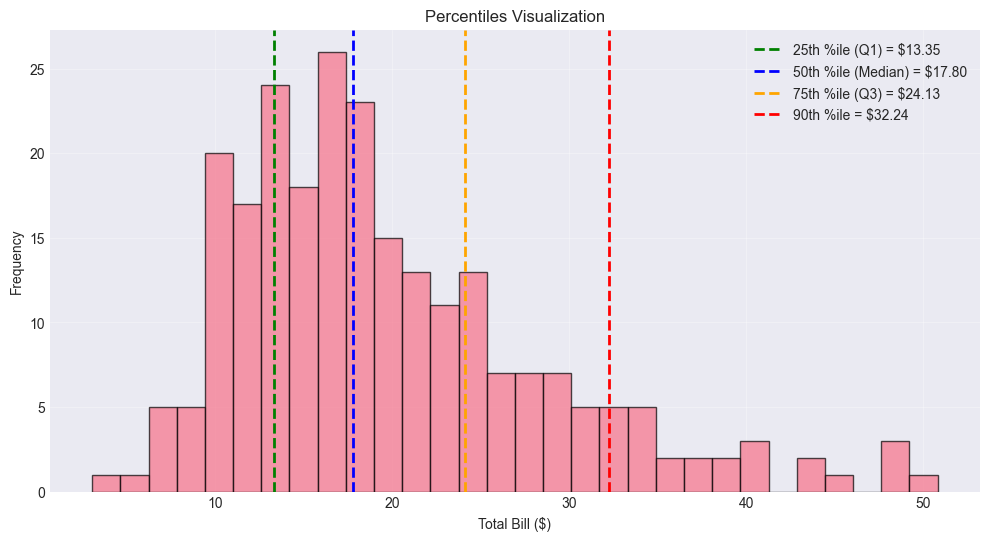


💡 Interpretation:
   25% bills are below $13.35
   50% bills are below $17.80
   75% bills are below $24.13
   90% bills are below $32.24


In [12]:
# Important percentiles
p25 = df['total_bill'].quantile(0.25)  # 25th percentile (Q1)
p50 = df['total_bill'].quantile(0.50)  # 50th percentile (Median)
p75 = df['total_bill'].quantile(0.75)  # 75th percentile (Q3)
p90 = df['total_bill'].quantile(0.90)  # 90th percentile
p95 = df['total_bill'].quantile(0.95)  # 95th percentile

print("📊 Percentiles of Total Bill:")
print(f"   25th percentile (Q1): ${p25:.2f}")
print(f"   50th percentile (Median): ${p50:.2f}")
print(f"   75th percentile (Q3): ${p75:.2f}")
print(f"   90th percentile: ${p90:.2f}")
print(f"   95th percentile: ${p95:.2f}")

# Visualization
plt.figure(figsize=(12, 6))
plt.hist(df['total_bill'], bins=30, alpha=0.7, edgecolor='black')
plt.axvline(p25, color='green', linestyle='--', linewidth=2, label=f'25th %ile (Q1) = ${p25:.2f}')
plt.axvline(p50, color='blue', linestyle='--', linewidth=2, label=f'50th %ile (Median) = ${p50:.2f}')
plt.axvline(p75, color='orange', linestyle='--', linewidth=2, label=f'75th %ile (Q3) = ${p75:.2f}')
plt.axvline(p90, color='red', linestyle='--', linewidth=2, label=f'90th %ile = ${p90:.2f}')
plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')
plt.title('Percentiles Visualization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 Interpretation:")
print(f"   25% bills are below ${p25:.2f}")
print(f"   50% bills are below ${p50:.2f}")
print(f"   75% bills are below ${p75:.2f}")
print(f"   90% bills are below ${p90:.2f}")

### 3.2 Percentage of Values (Custom Thresholds)

**Task**: Kitne percentage bills $20 se zyada hain?

📊 Bills above $20:
   Count: 97 out of 244
   Percentage: 39.75%
   93.0% bills > $10
   67.2% bills > $15
   39.8% bills > $20
   22.5% bills > $25
   13.1% bills > $30


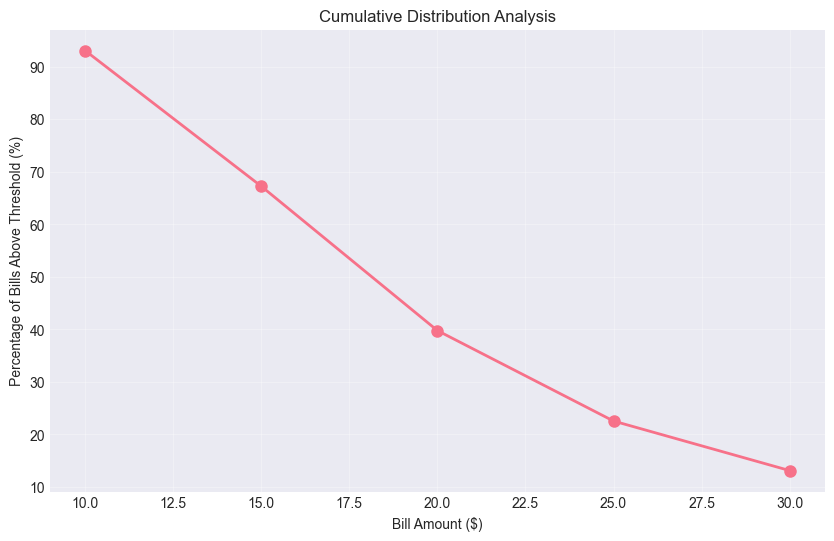


💡 Use Case: Restaurant pricing strategy - kitne customers high bills pay karte hain?


In [13]:
# Custom threshold analysis
threshold = 20

# Count values above threshold
above_threshold = df[df['total_bill'] > threshold]
percentage_above = (len(above_threshold) / len(df)) * 100

print(f"📊 Bills above ${threshold}:")
print(f"   Count: {len(above_threshold)} out of {len(df)}")
print(f"   Percentage: {percentage_above:.2f}%")

# Multiple thresholds
thresholds = [10, 15, 20, 25, 30]
percentages = []

for t in thresholds:
    pct = (df['total_bill'] > t).sum() / len(df) * 100
    percentages.append(pct)
    print(f"   {pct:.1f}% bills > ${t}")

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(thresholds, percentages, marker='o', linewidth=2, markersize=8)
plt.xlabel('Bill Amount ($)')
plt.ylabel('Percentage of Bills Above Threshold (%)')
plt.title('Cumulative Distribution Analysis')
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 Use Case: Restaurant pricing strategy - kitne customers high bills pay karte hain?")

---
## 📦 PART 4: Five Number Summary & Box Plot

### 4.1 Five Number Summary

**Components**:
1. Minimum
2. Q1 (25th percentile)
3. Median (50th percentile)
4. Q3 (75th percentile)
5. Maximum

In [14]:
# Five Number Summary - Manual
minimum = df['total_bill'].min()
q1 = df['total_bill'].quantile(0.25)
median = df['total_bill'].median()
q3 = df['total_bill'].quantile(0.75)
maximum = df['total_bill'].max()

print("📊 Five Number Summary:")
print(f"   1. Minimum:  ${minimum:.2f}")
print(f"   2. Q1:       ${q1:.2f}")
print(f"   3. Median:   ${median:.2f}")
print(f"   4. Q3:       ${q3:.2f}")
print(f"   5. Maximum:  ${maximum:.2f}")

# Using describe() - gives more info
print("\n📊 Using describe():")
print(df['total_bill'].describe())

# Interquartile Range (IQR)
iqr = q3 - q1
print(f"\n📊 Interquartile Range (IQR): ${iqr:.2f}")
print("   (Middle 50% of data is spread over this range)")

📊 Five Number Summary:
   1. Minimum:  $3.07
   2. Q1:       $13.35
   3. Median:   $17.80
   4. Q3:       $24.13
   5. Maximum:  $50.81

📊 Using describe():
count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64

📊 Interquartile Range (IQR): $10.78
   (Middle 50% of data is spread over this range)


### 4.2 Box Plot Theory & Visualization

**Box Plot Components**:
- Box: Q1 to Q3 (middle 50% data)
- Line inside box: Median
- Whiskers: 1.5 × IQR se extend
- Dots: Outliers

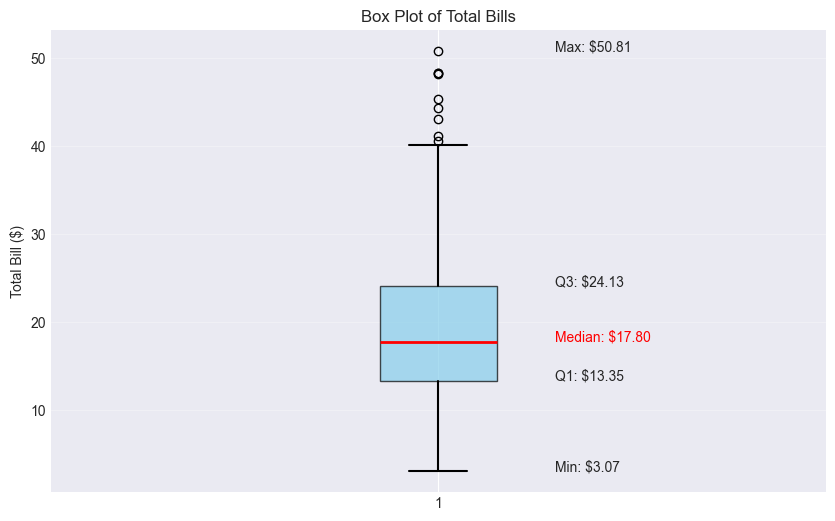


📊 Outlier Detection (IQR Method):
   Lower Bound: $-2.82
   Upper Bound: $40.30
   Number of Outliers: 9
   Outlier values: [48.27 44.3  41.19 48.17 50.81 45.35 40.55 43.11 48.33]


In [15]:
# Single Box Plot
plt.figure(figsize=(10, 6))
box = plt.boxplot(df['total_bill'], vert=True, patch_artist=True,
                  boxprops=dict(facecolor='skyblue', alpha=0.7),
                  medianprops=dict(color='red', linewidth=2),
                  whiskerprops=dict(linewidth=1.5),
                  capprops=dict(linewidth=1.5))

plt.ylabel('Total Bill ($)')
plt.title('Box Plot of Total Bills')
plt.grid(True, alpha=0.3, axis='y')

# Annotations
plt.text(1.15, minimum, f'Min: ${minimum:.2f}', fontsize=10)
plt.text(1.15, q1, f'Q1: ${q1:.2f}', fontsize=10)
plt.text(1.15, median, f'Median: ${median:.2f}', fontsize=10, color='red')
plt.text(1.15, q3, f'Q3: ${q3:.2f}', fontsize=10)
plt.text(1.15, maximum, f'Max: ${maximum:.2f}', fontsize=10)

plt.show()

# Outlier detection using IQR method
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['total_bill'] < lower_bound) | (df['total_bill'] > upper_bound)]
print(f"\n📊 Outlier Detection (IQR Method):")
print(f"   Lower Bound: ${lower_bound:.2f}")
print(f"   Upper Bound: ${upper_bound:.2f}")
print(f"   Number of Outliers: {len(outliers)}")
if len(outliers) > 0:
    print(f"   Outlier values: {outliers['total_bill'].values}")

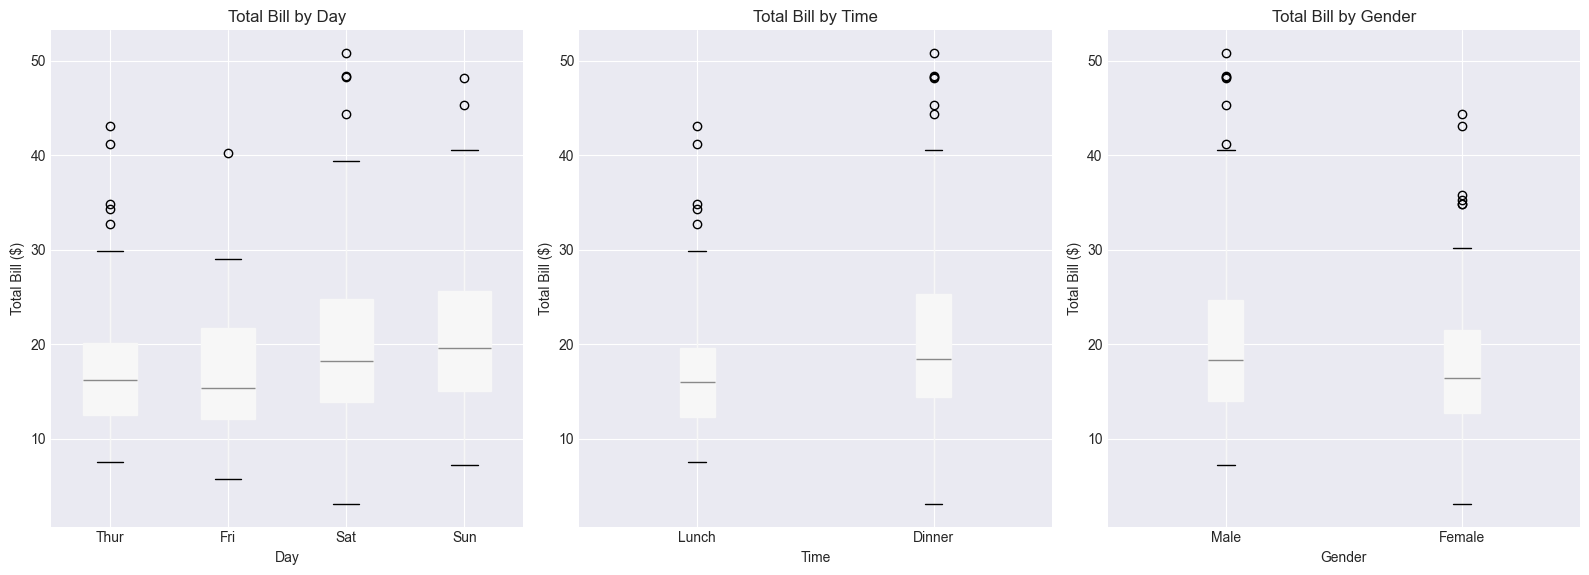

💡 Interpretation: Box plots se categories compare kar sakte ho


In [16]:


# Multiple Box Plots - Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Box plot by day
df.boxplot(column='total_bill', by='day', ax=axes[0], patch_artist=True)
axes[0].set_title('Total Bill by Day')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Total Bill ($)')

# Box plot by time
df.boxplot(column='total_bill', by='time', ax=axes[1], patch_artist=True)
axes[1].set_title('Total Bill by Time')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Total Bill ($)')

# Box plot by sex
df.boxplot(column='total_bill', by='sex', ax=axes[2], patch_artist=True)
axes[2].set_title('Total Bill by Gender')
axes[2].set_xlabel('Gender')
axes[2].set_ylabel('Total Bill ($)')

plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.show()

print("💡 Interpretation: Box plots se categories compare kar sakte ho")

---
## 🔗 PART 5: Covariance & Correlation

### 5.1 Covariance

**Formula**: Measure of how two variables change together

**Values**:
- Positive: Both increase together
- Negative: One increases, other decreases
- Zero: No linear relationship

**Problem**: Unit-dependent, hard to interpret

In [17]:
# Covariance between total_bill and tip
covariance = df[['total_bill', 'tip']].cov()
print("📊 Covariance Matrix:")
print(covariance)

# Extract specific covariance
cov_value = covariance.loc['total_bill', 'tip']
print(f"\n📊 Covariance between Total Bill and Tip: {cov_value:.2f}")

# NumPy method
cov_np = np.cov(df['total_bill'], df['tip'])[0, 1]
print(f"📊 Covariance (NumPy): {cov_np:.2f}")

print("\n💡 Interpretation:")
if cov_value > 0:
    print("   Positive covariance: Higher bills → Higher tips")
elif cov_value < 0:
    print("   Negative covariance: Higher bills → Lower tips")
else:
    print("   No covariance: No relationship")

print("\n⚠️ Problem: Covariance value hard to interpret (unit-dependent)")

📊 Covariance Matrix:
            total_bill       tip
total_bill   79.252939  8.323502
tip           8.323502  1.914455

📊 Covariance between Total Bill and Tip: 8.32
📊 Covariance (NumPy): 8.32

💡 Interpretation:
   Positive covariance: Higher bills → Higher tips

⚠️ Problem: Covariance value hard to interpret (unit-dependent)


### 5.2 Correlation (Pearson)

**Formula**: Covariance / (SD of X × SD of Y)

**Range**: -1 to +1
- +1: Perfect positive correlation
- 0: No correlation
- -1: Perfect negative correlation

**Interpretation**:
- 0.0 to 0.3: Weak
- 0.3 to 0.7: Moderate
- 0.7 to 1.0: Strong

In [2]:
# Correlation between total_bill and tip
correlation = df[['total_bill', 'tip']].corr()
print("📊 Correlation Matrix:")
print(correlation)

# Extract specific correlation
corr_value = correlation.loc['total_bill', 'tip']
print(f"\n📊 Correlation between Total Bill and Tip: {corr_value:.3f}")

# NumPy method
corr_np = np.corrcoef(df['total_bill'], df['tip'])[0, 1]
print(f"📊 Correlation (NumPy): {corr_np:.3f}")

# Scatter plot with correlation
plt.figure(figsize=(10, 6))
plt.scatter(df['total_bill'], df['tip'], alpha=0.6, edgecolors='black')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title(f'Correlation between Total Bill and Tip (r = {corr_value:.3f})')
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df['total_bill'], df['tip'], 1)
p = np.poly1d(z)
plt.plot(df['total_bill'], p(df['total_bill']), "r--", linewidth=2, label='Trend Line')
plt.legend()
plt.show()

print("\n💡 Interpretation:")
if abs(corr_value) >= 0.7:
    strength = "Strong"
elif abs(corr_value) >= 0.3:
    strength = "Moderate"
else:
    strength = "Weak"

direction = "positive" if corr_value > 0 else "negative"
print(f"   {strength} {direction} correlation")
print(f"   As total bill increases, tip also tends to increase")

NameError: name 'df' is not defined

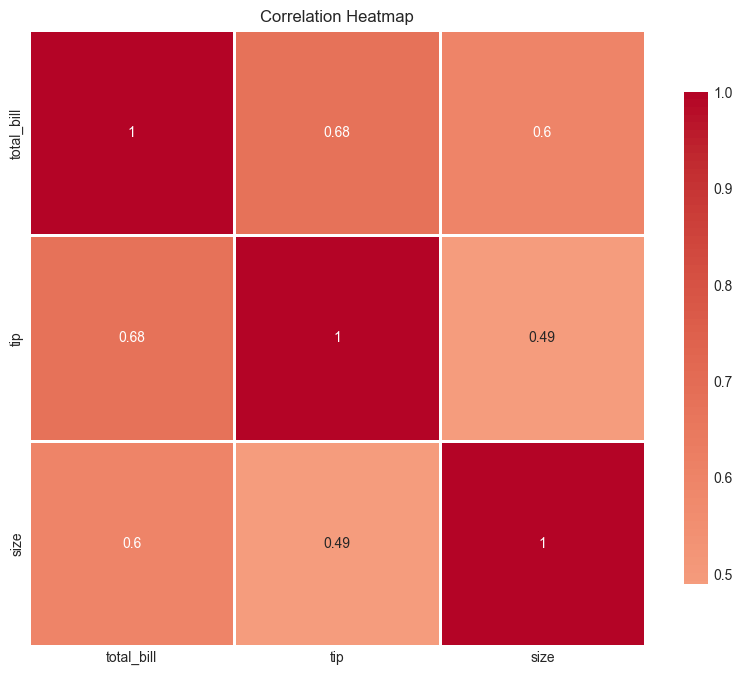

💡 Heatmap Reading:
   Red = Positive correlation
   Blue = Negative correlation
   White = No correlation


In [19]:
# Correlation Matrix Heatmap (All numerical columns)
plt.figure(figsize=(10, 8))
correlation_matrix = df[['total_bill', 'tip', 'size']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap')
plt.show()

print("💡 Heatmap Reading:")
print("   Red = Positive correlation")
print("   Blue = Negative correlation")
print("   White = No correlation")

---
## 🎯 FINAL PRACTICE: Complete Analysis

**Task**: `size` column (number of people) ka complete statistical analysis karo

COMPLETE STATISTICAL ANALYSIS - SIZE COLUMN

1️⃣ MEASURES OF CENTRAL TENDENCY:
   Mean: 2.57
   Median: 2.00
   Mode: 2

2️⃣ MEASURES OF DISPERSION:
   Range: 5
   Variance: 0.90
   Standard Deviation: 0.95
   Coefficient of Variation: 37.01%

3️⃣ PERCENTILES:
   25th percentile: 2.00
   50th percentile: 2.00
   75th percentile: 3.00

4️⃣ FIVE NUMBER SUMMARY:
count    244.000000
mean       2.569672
std        0.951100
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        6.000000
Name: size, dtype: float64


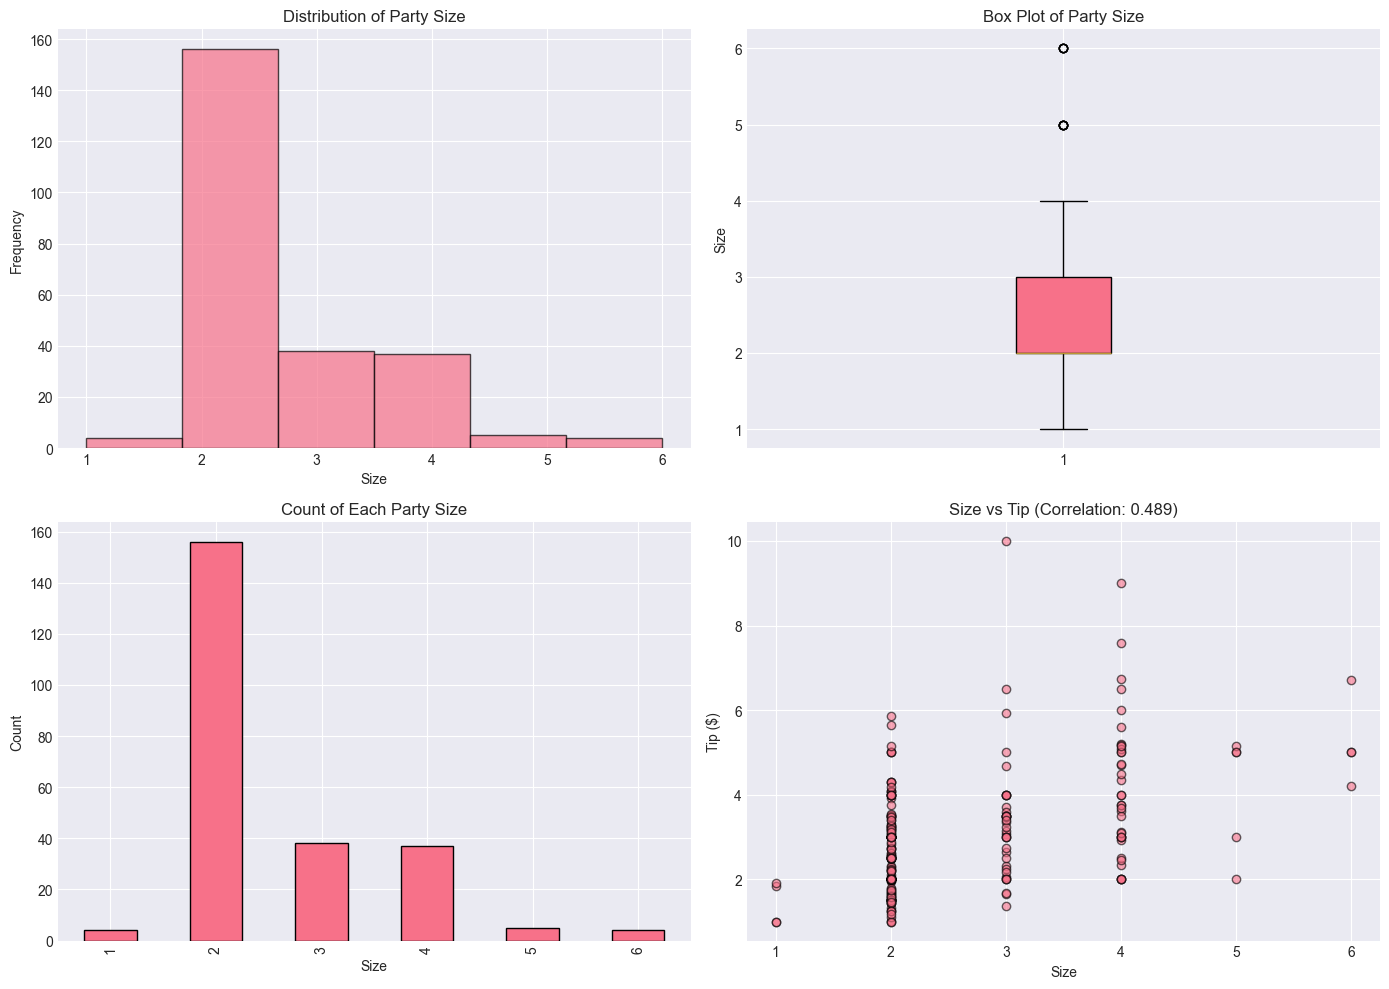


✅ ANALYSIS COMPLETE!


In [20]:
# YOUR COMPLETE ANALYSIS HERE

print("="*60)
print("COMPLETE STATISTICAL ANALYSIS - SIZE COLUMN")
print("="*60)

# 1. Central Tendency
print("\n1️⃣ MEASURES OF CENTRAL TENDENCY:")
print(f"   Mean: {df['size'].mean():.2f}")
print(f"   Median: {df['size'].median():.2f}")
print(f"   Mode: {df['size'].mode()[0]}")

# 2. Dispersion
print("\n2️⃣ MEASURES OF DISPERSION:")
print(f"   Range: {df['size'].max() - df['size'].min()}")
print(f"   Variance: {df['size'].var():.2f}")
print(f"   Standard Deviation: {df['size'].std():.2f}")
print(f"   Coefficient of Variation: {(df['size'].std() / df['size'].mean()) * 100:.2f}%")

# 3. Percentiles
print("\n3️⃣ PERCENTILES:")
print(f"   25th percentile: {df['size'].quantile(0.25):.2f}")
print(f"   50th percentile: {df['size'].quantile(0.50):.2f}")
print(f"   75th percentile: {df['size'].quantile(0.75):.2f}")

# 4. Five Number Summary
print("\n4️⃣ FIVE NUMBER SUMMARY:")
print(df['size'].describe())

# 5. Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(df['size'], bins=6, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Party Size')
axes[0, 0].set_xlabel('Size')
axes[0, 0].set_ylabel('Frequency')

# Box plot
axes[0, 1].boxplot(df['size'], vert=True, patch_artist=True)
axes[0, 1].set_title('Box Plot of Party Size')
axes[0, 1].set_ylabel('Size')

# Bar chart (value counts)
df['size'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], edgecolor='black')
axes[1, 0].set_title('Count of Each Party Size')
axes[1, 0].set_xlabel('Size')
axes[1, 0].set_ylabel('Count')

# Correlation with tip
axes[1, 1].scatter(df['size'], df['tip'], alpha=0.6, edgecolors='black')
axes[1, 1].set_title(f'Size vs Tip (Correlation: {df[["size", "tip"]].corr().iloc[0, 1]:.3f})')
axes[1, 1].set_xlabel('Size')
axes[1, 1].set_ylabel('Tip ($)')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("✅ ANALYSIS COMPLETE!")
print("="*60)

---
## 📚 SUMMARY & KEY TAKEAWAYS

### Concepts Covered:

**1. Central Tendency**
- Mean: Average value
- Median: Middle value (better for skewed data)
- Mode: Most frequent value

**2. Dispersion**
- Range: Max - Min
- Variance: Squared deviations from mean
- Standard Deviation: Square root of variance
- CV: Relative variability (unit-free)

**3. Percentiles**
- Divide data into 100 parts
- Useful for understanding distribution

**4. Five Number Summary**
- Min, Q1, Median, Q3, Max
- Foundation for box plots

**5. Box Plots**
- Visual representation of 5-number summary
- Shows outliers
- Great for comparing groups

**6. Covariance & Correlation**
- Covariance: Direction of relationship (unit-dependent)
- Correlation: Standardized measure (-1 to +1)
- Use correlation for interpretation

---

### Next Steps for Kaggle Practice:

1. **Try different datasets**:
   - Titanic
   - House Prices
   - Iris
   - Any dataset you find interesting

2. **For each dataset**:
   - Load data
   - Pick numerical columns
   - Apply all these concepts
   - Create visualizations
   - Write interpretations

3. **Build Portfolio**:
   - Create 3-5 EDA notebooks
   - Share on Kaggle
   - Add to GitHub

---

### Important Pandas/NumPy Functions:

```python
# Central Tendency
df['column'].mean()
df['column'].median()
df['column'].mode()

# Dispersion
df['column'].var()
df['column'].std()
df['column'].min()
df['column'].max()

# Percentiles
df['column'].quantile(0.25)  # Q1
df['column'].quantile(0.75)  # Q3

# Summary
df['column'].describe()

# Correlation
df[['col1', 'col2']].corr()
df[['col1', 'col2']].cov()
```

---

**🎉 Congratulations! Tumne saare statistics concepts practice kar liye!**

**Ab ML start karne ke liye ready ho! 🚀**